In [170]:
import pandas as pd
import numpy as np

In [ ]:
data = pd.read_csv("../data/data_part3.csv")

In [172]:
data.sample(5)

,Название,Цена,Дата,Телефон,Оператор,Контактное лицо (автор объявления),Тип автора,Регион,Город,Метро/Район,...,Источник,lat,lng,Персона для контактов,Доп.параметры,URL,Ссылки на картинки,Регион мобильного телефона,Номер подменён,"Расстояние до метро, км"
16549,"Коммерческая земля в Московская область, Чехов...",62870,2025-06-19 02:26:25,89153135209,Мобильные ТелеСистемы,"Министерство инвестиций, промышленности и наук...",Агентство,Московская область,Чехов муниципальный округ,NaN,...,cian.ru,55.147490,37.300360,NaN,Ед. измерения площади=сот.|Категория=Сельхозна...,https://www.cian.ru/rent/commercial/318874797,https://images.cdn-cian.ru/images/2529665709-1...,г. Москва и Московская область,да,неизвестно
3133,"Торговая площадь в Московская область, Ленинск...",270000,2025-07-22 18:25:35,89169629896,Мобильные ТелеСистемы,Агент S5D (S5D),Агентство,Московская область,Ленинский городской округ,Домодедовская,...,cian.ru,55.586344,37.753739,NaN,Этаж=1|Этажность здания=17|Тип объявления=Сдам...,https://www.cian.ru/rent/commercial/318566235,https://images.cdn-cian.ru/images/2518536155-1...,г. Москва и Московская область,да,7.333
9209,"Коммерческая земля в Московская область, Чехов...",62166,2025-07-07 02:24:36,89153135209,Мобильные ТелеСистемы,"Министерство инвестиций, промышленности и наук...",Агентство,Московская область,Чехов муниципальный округ,NaN,...,cian.ru,55.147147,37.299051,NaN,Ед. измерения площади=сот.|Категория=Сельхозна...,https://www.cian.ru/rent/commercial/319487036,https://images.cdn-cian.ru/images/2552880116-1...,г. Москва и Московская область,да,неизвестно
12922,"Коммерческая земля в Московская область, Талдо...",2212,2025-06-28 02:22:09,89153135209,Мобильные ТелеСистемы,"Министерство инвестиций, промышленности и наук...",Агентство,Московская область,Талдомский городской округ,NaN,...,cian.ru,56.805267,37.565102,NaN,Ед. измерения площади=сот.|Категория=Сельхозна...,https://www.cian.ru/rent/commercial/319196378,https://images.cdn-cian.ru/images/2543367160-1...,г. Москва и Московская область,да,неизвестно
2001,Помещение свободного назначения,120000,2025-07-25 18:52:50,89316409567,не определен,Мост Недвижимость,Агентство,Московская область,Истра,NaN,...,avito.ru,55.907465,36.861496,NaN,Этаж=-1|Тип объявления=Сдам|Вид объекта=Торгов...,https://www.avito.ru/istra/kommercheskaya_nedv...,https://00.img.avito.st/image/1/1.Z0s0Cba5y6IC...,не определен,да,неизвестно


In [173]:
data.isna().sum()

Название                                 82
Цена                                      0
Дата                                      0
Телефон                                   0
Оператор                                  0
Контактное лицо (автор объявления)       79
Тип автора                                0
Регион                                    0
Город                                     0
Метро/Район                            9329
Адрес                                  3339
Описание                                166
Тип объявления                            0
Категория1                                0
Категория2                                0
ID на сайте                               0
Источник                                  0
lat                                       0
lng                                       0
Персона для контактов                 20000
Доп.параметры                             0
URL                                       0
Ссылки на картинки              

In [174]:
data.columns

Index(['Название', 'Цена', 'Дата', 'Телефон', 'Оператор',
       'Контактное лицо (автор объявления)', 'Тип автора', 'Регион', 'Город',
       'Метро/Район', 'Адрес', 'Описание', 'Тип объявления', 'Категория1',
       'Категория2', 'ID на сайте', 'Источник', 'lat', 'lng',
       'Персона для контактов', 'Доп.параметры', 'URL', 'Ссылки на картинки',
       'Регион мобильного телефона', 'Номер подменён',
       'Расстояние до метро, км'],
      dtype='object')

In [175]:
data = data.drop(['Телефон', 'Оператор', 'Контактное лицо (автор объявления)', 'Персона для контактов', 
           'Регион мобильного телефона', 'Номер подменён', 'Тип объявления', 
           'Категория1', 'Категория2', ], axis=1)

In [176]:
data.columns

Index(['Название', 'Цена', 'Дата', 'Тип автора', 'Регион', 'Город',
       'Метро/Район', 'Адрес', 'Описание', 'ID на сайте', 'Источник', 'lat',
       'lng', 'Доп.параметры', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км'],
      dtype='object')

In [177]:
data["Сайт"] = data["Источник"]
data = data.set_index(['ID на сайте', 'Источник'])

In [178]:
data.sample(5)

,,Название,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,Доп.параметры,URL,Ссылки на картинки,"Расстояние до метро, км",Сайт
ID на сайте,Источник,,,,,,,,,,,,,,,,
319216418,cian.ru,"Коммерческая земля в Московская область, Талдо...",966,2025-06-29 02:23:53,Агентство,Московская область,Талдомский городской округ,NaN,NaN,Дата начала аукциона: 30.06.2025 09:00 Размер ...,56.565177,37.696144,Ед. измерения площади=сот.|Категория=Сельхозна...,https://www.cian.ru/rent/commercial/319216418,https://images.cdn-cian.ru/images/2544119107-1...,неизвестно,cian.ru
318590135,cian.ru,Помещение свободного назначения в Московская о...,135000,2025-07-06 18:25:24,Агентство,Московская область,Красногорск городской округ,Павшино,"ул. Заповедная, 13",Номер в базе: 5764919. Сдаётся уникальное поме...,55.773251,37.234585,Этаж=1|Этажность здания=9|Тип объявления=Сдам|...,https://www.cian.ru/rent/commercial/318590135,https://images.cdn-cian.ru/images/2519385724-1...,12.833,cian.ru
318992661,cian.ru,"Коммерческая земля в Московская область, Чехов...",61415,2025-06-23 02:25:39,Агентство,Московская область,Чехов муниципальный округ,NaN,NaN,Дата начала аукциона: 07.07.2025 09:00 Размер ...,55.146609,37.299457,Ед. измерения площади=сот.|Категория=Сельхозна...,https://www.cian.ru/rent/commercial/318992661,https://images.cdn-cian.ru/images/2534940039-1...,неизвестно,cian.ru
7489820166,avito.ru,"Склад, 5 м²",5000,2025-07-05 08:49:33,Агентство,Московская область,Химки,Сходня,"Московская обл., Химки, мкр-н Сходня, ул. Мико...",Сдaeм в аpeнду сухие боксы для хpанeния личных...,55.956739,37.286049,Этаж=1|Тип объявления=Сдам|Вид объекта=Складск...,https://www.avito.ru/himki/kommercheskaya_nedv...,https://50.img.avito.st/image/1/1.uVBHBra5Fblx...,1.1000000238419,avito.ru
254673567,cian.ru,"Офис в Московская область, Лобня ул. Монтажник...",40000,2025-07-17 22:23:55,Агентство,Московская область,Лобня,Лобня,"ул. Монтажников, 2",ПОД ПВЗ НЕ СДАЁТСЯ ТОЛЬКО ОФИС Сдается оф...,56.009114,37.462487,Этаж=1|Этажность здания=10|Тип объявления=Сдам...,https://www.cian.ru/rent/commercial/254673567,https://images.cdn-cian.ru/images/92/709/021/o...,1.5,cian.ru


In [179]:
data["Название"].fillna("")
data["Описание"].fillna("")
data["Описание"] = "НАЗВАНИЕ: " + data["Название"] + "\n\n" + "ОПИСАНИЕ" + data["Описание"]

In [180]:
data = data.drop(['Название'], axis=1)

In [181]:
def parse_parameters(v):
    return dict(pair.split("=") for pair in v.split("|"))
parse_parameters(data["Доп.параметры"].iloc[10])

{'Этаж': '2',
 'Этажность здания': '2',
 'Тип объявления': 'Сдам',
 'Вид объекта': 'Офисное помещение',
 'Общая площадь': '350'}

In [182]:
_ = data['Доп.параметры'].apply(parse_parameters)
params_parsed = pd.json_normalize(_)
params_parsed.index = data.index
params_parsed

,,Этаж,Этажность здания,Тип объявления,Вид объекта,Общая площадь,Класс здания,Ед. измерения площади,Категория
ID на сайте,Источник,,,,,,,,
3051474336517690558,realty.yandex.ru,10,19,Сдам,Офисное помещение,1829,NaN,NaN,NaN
2361989408025644208,realty.yandex.ru,2,3,Сдам,Офисное помещение,1200,NaN,NaN,NaN
3051474336517038876,realty.yandex.ru,4,20,Сдам,Офисное помещение,12803,NaN,NaN,NaN
2361989402784550867,realty.yandex.ru,1,1,Сдам,Офисное помещение,331,NaN,NaN,NaN
3051474287757807430,realty.yandex.ru,1,6,Сдам,Офисное помещение,1550,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
7310001813,avito.ru,0,NaN,Сдам,Помещение свободного назначения,26,NaN,NaN,NaN
7451408628,avito.ru,1,NaN,Сдам,Производственное помещение,678,NaN,NaN,NaN
7438225588,avito.ru,1,NaN,Сдам,Помещение свободного назначения,45,NaN,NaN,NaN


In [183]:
params_parsed.nunique()

Этаж                       32
Этажность здания           45
Тип объявления              1
Вид объекта                 8
Общая площадь            3654
Класс здания                4
Ед. измерения площади       2
Категория                   3
dtype: int64

In [184]:
params_parsed = params_parsed.drop(['Тип объявления', 'Класс здания'], axis=1)

In [185]:
data = pd.concat(
    [
        data.drop(["Доп.параметры"], axis=1),
        params_parsed
    ],
    axis=1
)
data

,,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Сайт,Этаж,Этажность здания,Вид объекта,Общая площадь,Ед. измерения площади,Категория
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,
3051474336517690558,realty.yandex.ru,2514325,2025-07-30 16:06:32,Агентство,Московская область,Химки,Химки,"Ленинградская улица, 25",НАЗВАНИЕ: Офис (1829 м²)\n\nОПИСАНИЕЛот №61663...,55.894115,37.431522,https://realty.ya.ru/offer/3051474336517690558/,https://avatars.mds.yandex.net/get-realty-offe...,1.583,realty.yandex.ru,10,19,Офисное помещение,1829,NaN,NaN
2361989408025644208,realty.yandex.ru,2160000,2025-07-30 16:06:31,Агентство,Московская область,Мытищи,Ростокино,"Октябрьский проспект, 5А",НАЗВАНИЕ: Офис (1200 м²)\n\nОПИСАНИЕЛот №79160...,55.900530,37.740273,https://realty.ya.ru/offer/2361989408025644208/,https://avatars.mds.yandex.net/get-realty-offe...,16.5,realty.yandex.ru,2,3,Офисное помещение,1200,NaN,NaN
3051474336517038876,realty.yandex.ru,17604124,2025-07-30 16:06:31,Агентство,Московская область,Химки,Химки,"Ленинградская улица, 25",НАЗВАНИЕ: Офис (12803 м²)\n\nОПИСАНИЕЛот №6166...,55.894115,37.431522,https://realty.ya.ru/offer/3051474336517038876/,https://avatars.mds.yandex.net/get-realty-offe...,1.583,realty.yandex.ru,4,20,Офисное помещение,12803,NaN,NaN
2361989402784550867,realty.yandex.ru,780002,2025-07-30 16:06:29,Агентство,Московская область,Долгопрудный,Новодачная,"Лихачёвский проспект, 8",НАЗВАНИЕ: Офис (331 м²)\n\nОПИСАНИЕЛот №836313...,55.912914,37.495570,https://realty.ya.ru/offer/2361989402784550867/,https://avatars.mds.yandex.net/get-realty-offe...,16.5,realty.yandex.ru,1,1,Офисное помещение,331,NaN,NaN
3051474287757807430,realty.yandex.ru,6509496,2025-07-30 16:06:29,Агентство,Московская область,Заречье,Немчиновка,"Весенняя улица, 2к6",НАЗВАНИЕ: Офис (1550 м²)\n\nОПИСАНИЕЛот №71698...,55.696087,37.402120,https://realty.ya.ru/offer/3051474287757807430/,https://avatars.mds.yandex.net/get-realty-offe...,21.083,realty.yandex.ru,1,6,Офисное помещение,1550,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7310001813,avito.ru,19500,2025-06-09 08:32:46,Агентство,Московская область,Апрелевка,Апрелевка,"Московская обл., Наро-Фоминский г.о., Апрелевк...","НАЗВАНИЕ: Свободного назначения, 26 м²\n\nОПИС...",55.540934,37.082832,https://www.avito.ru/aprelevka/kommercheskaya_...,https://80.img.avito.st/image/1/1.nWm9_La5MYCL...,1.3999999761581,avito.ru,0,NaN,Помещение свободного назначения,26,NaN,NaN
7451408628,avito.ru,750000,2025-06-09 08:29:45,Частное лицо (фильтр),Московская область,Одинцово,Одинцово,"Московская обл., Одинцовский г.о., Одинцово, С...","НАЗВАНИЕ: Производство, склад, 678 кв.м\n\nОПИ...",55.671228,37.283054,https://www.avito.ru/odintsovo/kommercheskaya_...,https://40.img.avito.st/image/1/1.OB41ALa5lPcD...,0.10000000149012,avito.ru,1,NaN,Производственное помещение,678,NaN,NaN
7438225588,avito.ru,140000,2025-06-09 08:21:47,Частное лицо (фильтр),Московская область,Красногорск,Пятницкое шоссе,"Московская обл., г.о. Красногорск, пгт. Путилк...","НАЗВАНИЕ: Свободного назначения, 45 м²\n\nОПИС...",55.867445,37.391664,https://www.avito.ru/moskovskaya_oblast_krasno...,https://10.img.avito.st/image/1/1.NlaoLLa5mr-e...,2.7000000476837,avito.ru,1,NaN,Помещение свободного назначения,45,NaN,NaN


In [186]:
data["Дата"] = pd.to_datetime(data["Дата"])
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 20000 entries, (np.int64(3051474336517690558), 'realty.yandex.ru') to (np.int64(7418142506), 'avito.ru')
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Цена                     20000 non-null  int64         
 1   Дата                     20000 non-null  datetime64[ns]
 2   Тип автора               20000 non-null  object        
 3   Регион                   20000 non-null  object        
 4   Город                    20000 non-null  object        
 5   Метро/Район              10671 non-null  object        
 6   Адрес                    16661 non-null  object        
 7   Описание                 19752 non-null  object        
 8   lat                      20000 non-null  float64       
 9   lng                      20000 non-null  float64       
 10  URL                      20000 non-null  object        
 11  Ссылки на карт

In [187]:
data[["Расстояние до метро, км"]] = data[["Расстояние до метро, км"]].replace("неизвестно", np.nan)

In [188]:
data[[
    "Расстояние до метро, км",
    "Этаж",
    "Общая площадь",
    "Этажность здания"
]] = data[[
    "Расстояние до метро, км",
    "Этаж",
    "Общая площадь",
    "Этажность здания"
]].astype(float)

In [189]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 20000 entries, (np.int64(3051474336517690558), 'realty.yandex.ru') to (np.int64(7418142506), 'avito.ru')
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Цена                     20000 non-null  int64         
 1   Дата                     20000 non-null  datetime64[ns]
 2   Тип автора               20000 non-null  object        
 3   Регион                   20000 non-null  object        
 4   Город                    20000 non-null  object        
 5   Метро/Район              10671 non-null  object        
 6   Адрес                    16661 non-null  object        
 7   Описание                 19752 non-null  object        
 8   lat                      20000 non-null  float64       
 9   lng                      20000 non-null  float64       
 10  URL                      20000 non-null  object        
 11  Ссылки на карт

In [190]:
data.loc[data["Ед. измерения площади"] == "сот.", "Общая площадь"] *= 100
data.loc[data["Ед. измерения площади"] == "га.", "Общая площадь"] *= 10000

In [191]:
data = data.drop(["Ед. измерения площади"], axis=1)
data

,,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Сайт,Этаж,Этажность здания,Вид объекта,Общая площадь,Категория
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,
3051474336517690558,realty.yandex.ru,2514325,2025-07-30 16:06:32,Агентство,Московская область,Химки,Химки,"Ленинградская улица, 25",НАЗВАНИЕ: Офис (1829 м²)\n\nОПИСАНИЕЛот №61663...,55.894115,37.431522,https://realty.ya.ru/offer/3051474336517690558/,https://avatars.mds.yandex.net/get-realty-offe...,1.583,realty.yandex.ru,10.0,19.0,Офисное помещение,1829.0,NaN
2361989408025644208,realty.yandex.ru,2160000,2025-07-30 16:06:31,Агентство,Московская область,Мытищи,Ростокино,"Октябрьский проспект, 5А",НАЗВАНИЕ: Офис (1200 м²)\n\nОПИСАНИЕЛот №79160...,55.900530,37.740273,https://realty.ya.ru/offer/2361989408025644208/,https://avatars.mds.yandex.net/get-realty-offe...,16.500,realty.yandex.ru,2.0,3.0,Офисное помещение,1200.0,NaN
3051474336517038876,realty.yandex.ru,17604124,2025-07-30 16:06:31,Агентство,Московская область,Химки,Химки,"Ленинградская улица, 25",НАЗВАНИЕ: Офис (12803 м²)\n\nОПИСАНИЕЛот №6166...,55.894115,37.431522,https://realty.ya.ru/offer/3051474336517038876/,https://avatars.mds.yandex.net/get-realty-offe...,1.583,realty.yandex.ru,4.0,20.0,Офисное помещение,12803.0,NaN
2361989402784550867,realty.yandex.ru,780002,2025-07-30 16:06:29,Агентство,Московская область,Долгопрудный,Новодачная,"Лихачёвский проспект, 8",НАЗВАНИЕ: Офис (331 м²)\n\nОПИСАНИЕЛот №836313...,55.912914,37.495570,https://realty.ya.ru/offer/2361989402784550867/,https://avatars.mds.yandex.net/get-realty-offe...,16.500,realty.yandex.ru,1.0,1.0,Офисное помещение,331.0,NaN
3051474287757807430,realty.yandex.ru,6509496,2025-07-30 16:06:29,Агентство,Московская область,Заречье,Немчиновка,"Весенняя улица, 2к6",НАЗВАНИЕ: Офис (1550 м²)\n\nОПИСАНИЕЛот №71698...,55.696087,37.402120,https://realty.ya.ru/offer/3051474287757807430/,https://avatars.mds.yandex.net/get-realty-offe...,21.083,realty.yandex.ru,1.0,6.0,Офисное помещение,1550.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7310001813,avito.ru,19500,2025-06-09 08:32:46,Агентство,Московская область,Апрелевка,Апрелевка,"Московская обл., Наро-Фоминский г.о., Апрелевк...","НАЗВАНИЕ: Свободного назначения, 26 м²\n\nОПИС...",55.540934,37.082832,https://www.avito.ru/aprelevka/kommercheskaya_...,https://80.img.avito.st/image/1/1.nWm9_La5MYCL...,1.400,avito.ru,0.0,NaN,Помещение свободного назначения,26.0,NaN
7451408628,avito.ru,750000,2025-06-09 08:29:45,Частное лицо (фильтр),Московская область,Одинцово,Одинцово,"Московская обл., Одинцовский г.о., Одинцово, С...","НАЗВАНИЕ: Производство, склад, 678 кв.м\n\nОПИ...",55.671228,37.283054,https://www.avito.ru/odintsovo/kommercheskaya_...,https://40.img.avito.st/image/1/1.OB41ALa5lPcD...,0.100,avito.ru,1.0,NaN,Производственное помещение,678.0,NaN
7438225588,avito.ru,140000,2025-06-09 08:21:47,Частное лицо (фильтр),Московская область,Красногорск,Пятницкое шоссе,"Московская обл., г.о. Красногорск, пгт. Путилк...","НАЗВАНИЕ: Свободного назначения, 45 м²\n\nОПИС...",55.867445,37.391664,https://www.avito.ru/moskovskaya_oblast_krasno...,https://10.img.avito.st/image/1/1.NlaoLLa5mr-e...,2.700,avito.ru,1.0,NaN,Помещение свободного назначения,45.0,NaN


In [192]:
data.loc[7310001813, "avito.ru"]['URL']

'https://www.avito.ru/aprelevka/kommercheskaya_nedvizhimost/svobodnogo_naznacheniya_26_m_7310001813'

In [193]:
# !pip install matplotlib

In [194]:
# !pip install seaborn

In [195]:
import matplotlib.pyplot as plt
import seaborn as sns

In [196]:
data.columns

Index(['Цена', 'Дата', 'Тип автора', 'Регион', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Сайт', 'Этаж', 'Этажность здания',
       'Вид объекта', 'Общая площадь', 'Категория'],
      dtype='object')

In [197]:
data["Вид объекта"].unique()

array(['Офисное помещение', 'Помещение свободного назначения',
       'Торговое помещение', 'Производственное помещение',
       'Складское помещение', 'Здание', nan, 'Коммерческая земля',
       'Гостиница'], dtype=object)

In [198]:
data = data[data["Вид объекта"] != "Складское помещение"].copy()
data = data[data["Вид объекта"] != "Коммерческая земля"].copy()
data = data[data["Вид объекта"] != "Производственное помещение"].copy()
data = data[data["Вид объекта"] != "Офисное помещение"].copy()
data = data[data["Вид объекта"] != "Гостиница"].copy()
# data = data[data["Вид объекта"] != "Здание"].copy()
data = data[data["Общая площадь"] <= 2000].copy()
data = data[data["Общая площадь"] >= 20].copy()

In [199]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 6279 entries, (np.int64(7545602119), 'avito.ru') to (np.int64(7439774369), 'avito.ru')
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Цена                     6279 non-null   int64         
 1   Дата                     6279 non-null   datetime64[ns]
 2   Тип автора               6279 non-null   object        
 3   Регион                   6279 non-null   object        
 4   Город                    6279 non-null   object        
 5   Метро/Район              3837 non-null   object        
 6   Адрес                    6233 non-null   object        
 7   Описание                 6176 non-null   object        
 8   lat                      6279 non-null   float64       
 9   lng                      6279 non-null   float64       
 10  URL                      6279 non-null   object        
 11  Ссылки на картинки       6186 no

In [200]:
data["Вид объекта"].value_counts()

Вид объекта
Помещение свободного назначения    4452
Торговое помещение                 1438
Здание                              176
Name: count, dtype: int64

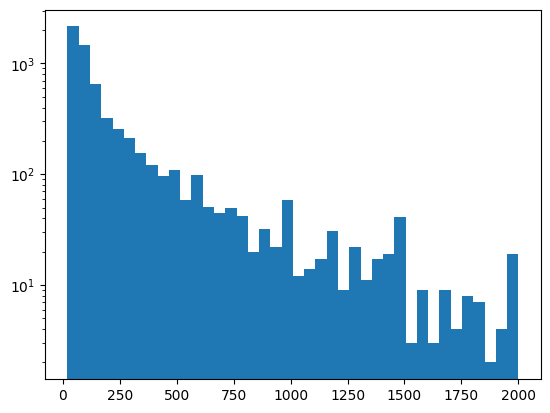

In [201]:
plt.hist(data["Общая площадь"], bins=40)
plt.yscale("log")
plt.show()

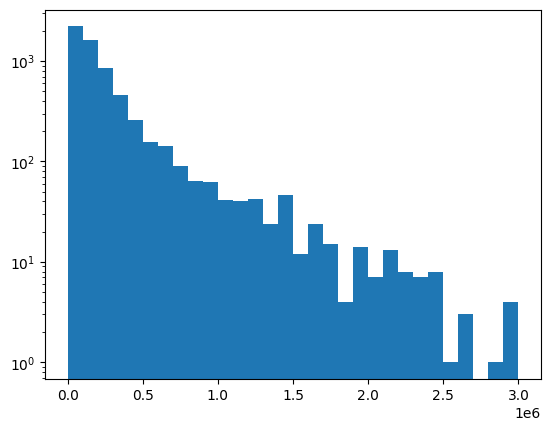

In [202]:
plt.hist(data["Цена"][data["Цена"] <= 3000000], bins=30)
# plt.xscale("log")
plt.yscale("log")
plt.show()

In [203]:
data = data.drop(["Категория"], axis=1)
bc_data = data[data["Цена"] > 2000000].copy()
data = data[data["Цена"] <= 2000000].copy()
data = data[data["Цена"] >= 20000].copy()

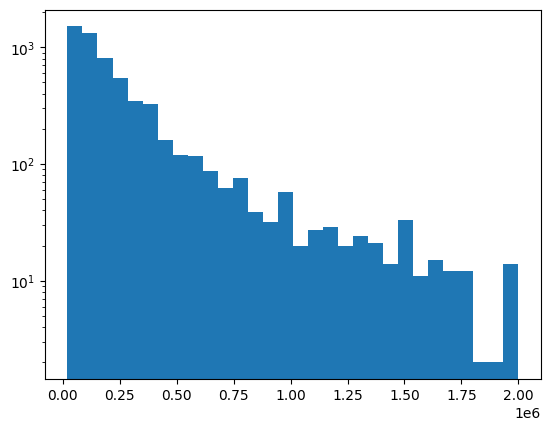

In [204]:
plt.hist(data["Цена"], bins=30)
plt.yscale("log")
plt.show()

In [205]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 5869 entries, (np.int64(7545602119), 'avito.ru') to (np.int64(7439774369), 'avito.ru')
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Цена                     5869 non-null   int64         
 1   Дата                     5869 non-null   datetime64[ns]
 2   Тип автора               5869 non-null   object        
 3   Регион                   5869 non-null   object        
 4   Город                    5869 non-null   object        
 5   Метро/Район              3661 non-null   object        
 6   Адрес                    5829 non-null   object        
 7   Описание                 5772 non-null   object        
 8   lat                      5869 non-null   float64       
 9   lng                      5869 non-null   float64       
 10  URL                      5869 non-null   object        
 11  Ссылки на картинки       5782 no

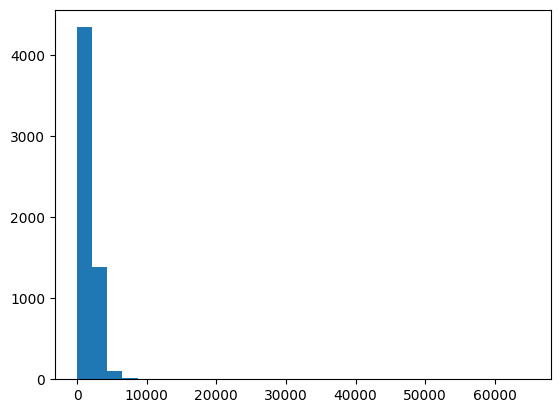

In [206]:
plt.hist(data["Цена"] / data["Общая площадь"], bins=30)
plt.show()

In [214]:
data["Сайт"].value_counts()

Сайт
avito.ru            3169
cian.ru             2305
realty.yandex.ru     395
Name: count, dtype: int64

In [213]:
data[(data["Цена"] / data["Общая площадь"] >= 10000)]

,,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Сайт,Этаж,Этажность здания,Вид объекта,Общая площадь
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
7539448744,avito.ru,520000,2025-07-27 23:11:53,Частное лицо (фильтр),Московская область,Королев,NaN,"Московская обл., Королёв, ул. Карла Маркса, 2А","НАЗВАНИЕ: Торговая площадь, 41 м²\n\nОПИСАНИЕB...",55.925031,37.817573,https://www.avito.ru/korolev/kommercheskaya_ne...,https://00.img.avito.st/image/1/1.MYwe4La5nWUo...,NaN,avito.ru,1.0,NaN,Торговое помещение,41.0
319860091,cian.ru,1944000,2025-07-24 16:23:01,Агентство,Московская область,Люберцы городской округ,Панки,35к1,НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.657047,37.920439,https://www.cian.ru/rent/commercial/319860091,https://images.cdn-cian.ru/images/nezhiloe-pom...,1.750,cian.ru,1.0,15.0,Помещение свободного назначения,30.0
7507309999,avito.ru,200000,2025-07-08 15:50:03,Частное лицо (фильтр),Московская область,Щёлково,NaN,"Московская обл., Щёлково, Пролетарский пр-т, 11","НАЗВАНИЕ: Торговая площадь, 20 м²\n\nОПИСАНИЕВ...",55.926856,38.000274,https://www.avito.ru/schelkovo/kommercheskaya_...,https://10.img.avito.st/image/1/1.K5eYxba5h36u...,NaN,avito.ru,1.0,NaN,Торговое помещение,20.0
7464980491,avito.ru,429000,2025-07-08 07:35:00,Агентство,Московская область,Реутов,Реутов,"Московская обл., Реутов, ул. Октября, вл10","НАЗВАНИЕ: Сдам коворкинг, 28 м²\n\nОПИСАНИЕЭкв...",55.751898,37.859201,https://www.avito.ru/reutov/kommercheskaya_ned...,https://70.img.avito.st/image/1/1.NxlQRLa5m_Bm...,0.200,avito.ru,NaN,NaN,NaN,28.0
293381420,cian.ru,1428000,2025-07-07 06:39:59,Агентство,Московская область,Люберцы,Люберцы,"Инициативная ул., 7В",НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.684950,37.896553,https://www.cian.ru/rent/commercial/293381420,NaN,0.500,cian.ru,1.0,26.0,Помещение свободного назначения,102.0
3965285094499622214,realty.yandex.ru,699999,2025-07-03 09:04:00,Агентство,Московская область,Котельники,Котельники,"Сосновая улица, 5к1",НАЗВАНИЕ: Помещение свободного назначения (55 ...,55.672470,37.856434,https://realty.ya.ru/offer/3965285094499622214/,https://avatars.mds.yandex.net/get-realty-offe...,0.417,realty.yandex.ru,1.0,30.0,Помещение свободного назначения,55.0
7431656486,avito.ru,372000,2025-06-26 13:17:47,Агентство,Московская область,Красногорск,Красногорская,"Московская обл., Красногорск, ул. Ленина, 35А",НАЗВАНИЕ: Торговое помещение в ТЦ\n\nОПИСАНИЕО...,55.829466,37.308184,https://www.avito.ru/moskovskaya_oblast_krasno...,https://40.img.avito.st/image/1/1.FtjUera5ujHi...,1.700,avito.ru,1.0,NaN,Торговое помещение,24.8
4531130661566887103,realty.yandex.ru,372000,2025-06-26 13:00:55,Агентство,Московская область,Красногорск,Красногорская,"улица Ленина, 35А",НАЗВАНИЕ: Торговая площадь (24.8 м²)\n\nОПИСАН...,55.829468,37.308186,https://realty.ya.ru/offer/4531130661566887103/,https://avatars.mds.yandex.net/get-realty-offe...,8.250,realty.yandex.ru,1.0,4.0,Торговое помещение,24.8
7482720581,avito.ru,300000,2025-06-26 00:16:30,Агентство,Московская область,Красногорск,Красногорская,"Московская обл., Красногорск, ул. Ленина, 35А",НАЗВАНИЕ: 25м2 на трафике Азбуки Вкуса\n\nОПИС...,55.829577,37.308094,https://www.avito.ru/moskovskaya_oblast_krasno...,https://00.img.avito.st/image/1/1.WvNr1ba59hpd...,1.700,avito.ru,1.0,NaN,Помещение свободного назначения,24.8


In [211]:
bc_data[(bc_data["Цена"] / bc_data["Общая площадь"]) >= 10000]

,,Цена,Дата,Тип автора,Регион,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Сайт,Этаж,Этажность здания,Вид объекта,Общая площадь
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
320105735,cian.ru,16976400,2025-07-29 16:23:50,Агентство,Московская область,Лобня,Лобня,"ул. Жирохова, 1",НАЗВАНИЕ: Помещение свободного назначения в Мо...,56.025120,37.471964,https://www.cian.ru/rent/commercial/320105735,https://images.cdn-cian.ru/images/nezhiloe-pom...,1.917,cian.ru,2.0,2.0,Помещение свободного назначения,132.0
316763060,cian.ru,19500000,2025-07-27 16:25:33,Агентство,Московская область,Домодедово городской округ,Зябликово,"ул. Мезенцева, 14",НАЗВАНИЕ: Торговая площадь в Московская област...,55.496251,37.738629,https://www.cian.ru/rent/commercial/316763060,https://images.cdn-cian.ru/images/2466647598-1...,19.250,cian.ru,1.0,16.0,Торговое помещение,83.0
7529326673,avito.ru,250000000,2025-07-21 17:04:17,Агентство,Московская область,Красногорск,NaN,"Московская обл., г.о. Красногорск, пос. Ильинс...",НАЗВАНИЕ: ПСН в ЖК Ильинские Луга \n\nОПИСАНИ...,55.770861,37.228557,https://www.avito.ru/moskovskaya_oblast_krasno...,https://90.img.avito.st/image/1/1.UQiRRra5_eGn...,NaN,avito.ru,1.0,NaN,Торговое помещение,66.2
319935074,cian.ru,2400000,2025-07-20 18:26:05,Агентство,Московская область,Подольск городской округ,Подольск,100,НАЗВАНИЕ: Помещение свободного назначения в Мо...,55.312491,37.535161,https://www.cian.ru/rent/commercial/319935074,https://images.cdn-cian.ru/images/nezhiloe-pom...,18.333,cian.ru,1.0,1.0,Помещение свободного назначения,60.0
319934072,cian.ru,2979920,2025-07-20 16:24:52,Агентство,Московская область,Дмитровский муниципальный округ,Хлебниково,11,НАЗВАНИЕ: Торговая площадь в Московская област...,56.130999,37.499237,https://www.cian.ru/rent/commercial/319934072,https://images.cdn-cian.ru/images/torgovoe-pom...,27.500,cian.ru,1.0,2.0,Торговое помещение,39.0
7543533110,avito.ru,7200000,2025-07-15 17:45:52,Частное лицо (фильтр),Московская область,Поварово,NaN,"Московская обл., г.о. Солнечногорск, пгт. Раду...","НАЗВАНИЕ: Свободного назначения, 600 м²\n\nОПИ...",56.075294,37.120068,https://www.avito.ru/povarovo/kommercheskaya_n...,https://30.img.avito.st/image/1/1.YuYizLa5zg8U...,NaN,avito.ru,1.0,NaN,Помещение свободного назначения,600.0
318965740,cian.ru,11400000,2025-07-11 22:24:08,Частное лицо (фильтр),Московская область,Руза,NaN,"Федеративная ул., 40","НАЗВАНИЕ: Здание в Московская область, Руза Фе...",55.709282,36.199429,https://www.cian.ru/rent/commercial/318965740,https://images.cdn-cian.ru/images/zdanie-ruza-...,NaN,cian.ru,NaN,1.0,Здание,114.0
319667210,cian.ru,55200000,2025-07-11 16:22:38,Агентство,Московская область,Истра,NaN,"Московская ул., 56",НАЗВАНИЕ: Торговая площадь в Московская област...,55.903847,36.896324,https://www.cian.ru/rent/commercial/319667210,https://images.cdn-cian.ru/images/2558437775-1...,NaN,cian.ru,2.0,2.0,Торговое помещение,276.0
319588857,cian.ru,1137616000,2025-07-09 16:25:35,Агентство,Московская область,Балашиха,Железнодорожная,"Железнодорожный мкр, ул. Некрасова, 4","НАЗВАНИЕ: Здание в Московская область, Балаших...",55.749527,37.997236,https://www.cian.ru/rent/commercial/319588857,https://images.cdn-cian.ru/images/zdanie-zhele...,0.917,cian.ru,NaN,2.0,Здание,1173.0


In [209]:
_ = data[data["Сайт"] != "avito.ru"][(data["Цена"].astype(int) % 12 == 0) & (data["Цена"] / data["Общая площадь"] > 5000)].iloc[6]
print("Цена:", _["Цена"])
print("URL:", _["URL"])

Цена: 450000
URL: https://realty.ya.ru/offer/3965285094499622192/


C:\Users\misha\AppData\Local\Temp\ipykernel_7232\3348051131.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  _ = data[data["Сайт"] != "avito.ru"][(data["Цена"].astype(int) % 12 == 0) & (data["Цена"] / data["Общая площадь"] > 5000)].iloc[6]
